<a href="https://colab.research.google.com/github/Koyel1234/ai-ml-learning-journey/blob/main/google_colab_notebooks/nitish_singh/genai_notebooks/LangGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Library Load

In [ ]:
!pip install langgraph

In [ ]:
!pip install langchain-huggingface

In [ ]:
!pip install transformers

# Understanding LANGGRAPH Components - Sequential Workflow (Non-LLM Workflow)

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [ ]:
# define state
class BMIState(TypedDict):
  weight_kg: float
  height_m: float
  bmi: float

In [ ]:
def calculate_bmi(state: BMIState) -> BMIState:
  weight = state['weight_kg']
  height = state['height_m']
  bmi = weight/(height**2)
  state['bmi'] = round(bmi, 2)
  return state

In [ ]:
# define graph
graph = StateGraph(BMIState)

# add nodes to graph
graph.add_node('calculate_bmi', calculate_bmi)

# add edges to graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', END)

# compile the graph
workflow= graph.compile()

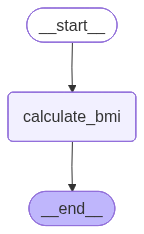

In [ ]:
workflow

In [ ]:
# execute the graph
initial_state = {'weight_kg': 80, 'height_m': 1.73}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73}


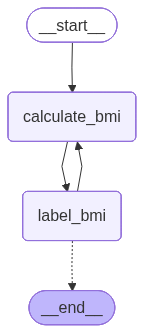

In [ ]:
class BMIState(TypedDict):
  weight_kg: float
  height_m: float
  bmi: float
  category: str

def calculate_bmi(state: BMIState) -> BMIState:
  weight = state['weight_kg']
  height = state['height_m']
  bmi = weight/(height**2)
  state['bmi'] = round(bmi, 2)
  return state


def label_bmi(state: BMIState) -> BMIState:
  bmi = state['bmi']
  if bmi<18.5:
    state['category'] = "Underweight"
  elif 18.5<bmi<25:
    state['category'] = "Normal"
  elif 25<bmi<30:
    state['category'] = "Overweight"
  else:
    state['category'] = 'Obese'
  return state

# define graph
graph = StateGraph(BMIState)

# add nodes to graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

# add edges to graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', 'calculate_bmi')

# compile the graph
workflow = graph.compile()
workflow

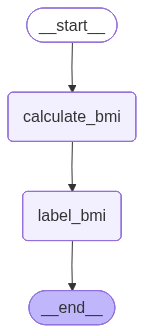

In [ ]:
# define graph
graph = StateGraph(BMIState)

# add nodes to graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

# add edges to graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)

# compile the graph
workflow = graph.compile()
workflow

In [ ]:
# execute the graph
initial_state = {'weight_kg': 80, 'height_m': 1.73}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


# Understanding LANGGRAPH Components - Sequential Workflow (LLM Workflow)

In [ ]:
from langgraph.graph import StateGraph

# from langchain_openai import ChatOpenAI
# from dotenv import load_dotenv # create a .env file, put api_kei there named `OPENAI_API_KEY`
# load_dotenv()
# model = ChatOpenAI()
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage
import re

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Answer clearly and directly."),
    ("human", "{input}")
])

llm_pipeline = HuggingFacePipeline.from_model_id(
    model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    task = "text-generation",
    pipeline_kwargs = dict(
        temperature = 0.5,
        max_new_tokens = 100
    )
)

model = ChatHuggingFace(llm=llm_pipeline)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [ ]:
class LLMState(TypedDict):
  question: str
  answer: str

In [ ]:
def llm_qa(state: LLMState) -> LLMState:

  # extract the question from state
  question = state['question']

  # form a prompt
  prompt = f"Answer the following question: {question}"

  # ask that question to the LLM
  answer = model.invoke(prompt).content

  # update the answer in the state
  state['answer'] = answer

  return state

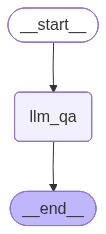

In [ ]:
graph = StateGraph(LLMState)

graph.add_node('llm_qa', llm_qa)

graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

workflow = graph.compile()
workflow

In [ ]:
initial_state = {'question': 'How far is moon from Earth?'}
final_state = workflow.invoke(initial_state)
final_state

Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'question': 'How far is moon from Earth?',
 'answer': '<|user|>\nAnswer the following question: How far is moon from Earth?</s>\n<|assistant|>\nThe distance between moon and Earth is approximately 238,900 kilometers (148,000 miles).'}

# Sequential Workflow - Prompt Chaining

In [ ]:
from langgraph.graph import StateGraph

# from langchain_openai import ChatOpenAI
# from dotenv import load_dotenv # create a .env file, put api_kei there named `OPENAI_API_KEY`
# load_dotenv()
# model = ChatOpenAI()
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage
import re

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Answer clearly and directly."),
    ("human", "{input}")
])

llm_pipeline = HuggingFacePipeline.from_model_id(
    model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    task = "text-generation",
    pipeline_kwargs = dict(
        temperature = 0.5,
        max_new_tokens = 100
    )
)

model = ChatHuggingFace(llm=llm_pipeline)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
class BlogState(TypedDict):
  title: str
  outline: str
  content: str

In [ ]:
def create_outline(state: BlogState) -> BlogState:
  # fetch title
  title = state['title']
  # call llm gen outline
  prompt = f"Generate a detailed outline for a blog on the topic - {title}"
  outline = model.invoke(prompt)
  # update state
  state['outline'] = outline
  return state



In [ ]:
def create_blog(state: BlogState) -> BlogState:
  # fetch title and outline
  title = state['title']
  outline = state['outline']
  # call llm gen outline
  prompt = f"Generate a detailed blog on the title - {title} using the following \n {outline}"
  content = model.invoke(prompt)
  # update state
  state['content'] = content
  return state

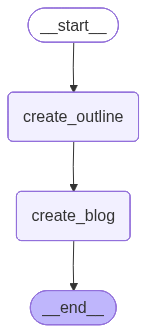

In [ ]:
graph = StateGraph(BlogState)

graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()
workflow

In [ ]:
initial_state = {'title': 'Rise of AI in India'}
final_state = workflow.invoke(initial_state)
print(final_state)

Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'title': 'Rise of AI in India', 'outline': AIMessage(content="<|user|>\nGenerate a detailed outline for a blog on the topic - Rise of AI in India</s>\n<|assistant|>\nTitle: The Rise of AI in India: A Brighter Future\n\nIntroduction:\n\nArtificial Intelligence (AI) has been transforming the world in recent years, with India being no exception. India is expected to become one of the world's largest AI markets by 2025, with a projected growth rate of 17.5% by 2025. This article aims to provide an overview of the rise", additional_kwargs={}, response_metadata={}, id='lc_run--019dd95b-752e-7c60-ae03-289884196c39-0', tool_calls=[], invalid_tool_calls=[]), 'content': AIMessage(content='<|user|>\nGenerate a detailed blog on the topic - Rise of AI in India using the following \n content="<|user|>\\nGenerate a detailed outline for a blog on the topic - Rise of AI in India</s>\\n<|assistant|>\\nTitle: The Rise of AI in India: A Brighter Future\\n\\nIntroduction:\\n\\nArtificial Intelligence (AI)

In [ ]:
print(final_state.keys())

dict_keys(['title', 'outline', 'content'])


In [ ]:
print(final_state['title'])

Rise of AI in India


In [ ]:
print(final_state['outline'])

content="<|user|>\nGenerate a detailed outline for a blog on the topic - Rise of AI in India</s>\n<|assistant|>\nTitle: The Rise of AI in India: A Brighter Future\n\nIntroduction:\n\nArtificial Intelligence (AI) has been transforming the world in recent years, with India being no exception. India is expected to become one of the world's largest AI markets by 2025, with a projected growth rate of 17.5% by 2025. This article aims to provide an overview of the rise" additional_kwargs={} response_metadata={} id='lc_run--019dd95b-752e-7c60-ae03-289884196c39-0' tool_calls=[] invalid_tool_calls=[]


In [ ]:
print(final_state['content'])

content='<|user|>\nGenerate a detailed blog on the topic - Rise of AI in India using the following \n content="<|user|>\\nGenerate a detailed outline for a blog on the topic - Rise of AI in India</s>\\n<|assistant|>\\nTitle: The Rise of AI in India: A Brighter Future\\n\\nIntroduction:\\n\\nArtificial Intelligence (AI) has been transforming the world in recent years, with India being no exception. India is expected to become one of the world\'s largest AI markets by 2025, with a projected growth rate of 17.5% by 2025. This article aims to provide an overview of the rise" additional_kwargs={} response_metadata={} id=\'lc_run--019dd95b-752e-7c60-ae03-289884196c39-0\' tool_calls=[] invalid_tool_calls=[]</s>\n<|assistant|>\nTitle: The Rise of AI in India: A Brighter Future\n\nIntroduction\n\nArtificial Intelligence (AI) has been transforming the world in recent years, and India is no exception. India is expected to become one of the world\'s largest AI markets by 2025, with a projected gro

In [ ]:
# add node to evaluate - based on {outline} read my blog, generate an int score

# Parallel Workflow - Non-LLM Based

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [ ]:
class BatsmanState(TypedDict):
  runs: int
  balls: int
  fours: int
  sixes: int

  sr: float
  bpb: float
  boundary_percent: float
  summary: str

In [ ]:
def calculate_sr(state: BatsmanState):
  sr = (state['runs']/state['balls'])*100
  # state['sr'] = sr
  # return state
  return {'sr': sr}

def calculate_bpb(state: BatsmanState):
  bpb = state['balls']/(state['fours']+state['sixes'])
  # state['bpb'] = bpb
  # return state
  return {'bpb': bpb}

def calculate_boundary_percent(state: BatsmanState):
  boundary_percent = (((state['fours']*4) + (state['sixes']*6))/state['runs'])*100
  # state['boundary_percent'] = boundary_percent
  # return state
  return {'boundary_percent': boundary_percent}

def summary(state: BatsmanState):
  summary = f"""
  Strike Rate - {state['sr']} \n
  Balls per boundary - {state['bpb']} \n
  Boundary percent - {state['boundary_percent']} """
  # state['summary'] = summary
  # return state
  return {'summary': summary}

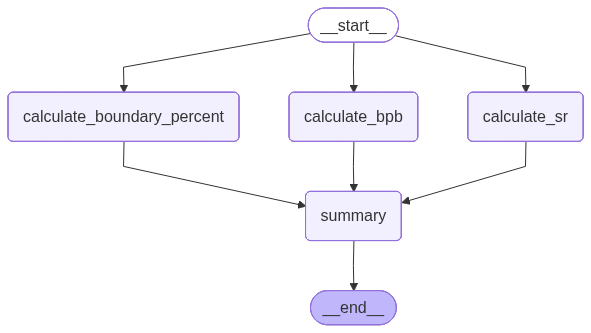

In [ ]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary)

graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percent')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()
workflow

In [ ]:
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_percent': 48.0,
 'summary': '\n  Strike Rate - 200.0 \n\n  Balls per boundary - 5.0 \n\n  Boundary percent - 48.0 '}

# Parallel Workflow - LLM Based

In [ ]:
from langgraph.graph import StateGraph, START, END
# from langchain_openai import ChatOpenAI
# from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator
# load_dotenv()
# model = ChatOpenAI(model = 'gpt-4o-mini)
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage
import re

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Answer clearly and directly."),
    ("human", "{input}")
])

llm_pipeline = HuggingFacePipeline.from_model_id(
    model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    task = "text-generation",
    pipeline_kwargs = dict(
        temperature = 0.5,
        max_new_tokens = 100
    )
)

model = ChatHuggingFace(llm=llm_pipeline)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
class EvaluationSchema(BaseModel):
  feedback: str = Field(description='Detailed feedback for the essay')
  score: int = Field(description = 'score out of 10', ge=0, le=10)

In [ ]:
# to get output in mentioned format of EvaluationSchema
structured_model = model.with_structured_output(EvaluationSchema)

NotImplementedError: Pydantic schema is not supported for function calling

In [ ]:
essay = """India is rapidly emerging as a significant player in the field of Artificial Intelligence (AI), shaping both its domestic growth and its global influence. With a large pool of skilled professionals, a strong IT industry, and increasing government support, India is positioning itself as a hub for AI innovation and development.

One of the key strengths of India in AI lies in its vast talent base. Every year, thousands of engineers and data scientists graduate from Indian institutions, contributing to the growing workforce in AI and related technologies. Indian professionals are actively involved in developing AI solutions across industries such as healthcare, agriculture, finance, and education.

The government of India has also taken several initiatives to promote AI. Programs like the National Strategy for Artificial Intelligence focus on using AI for social good. The aim is to improve areas such as healthcare services, smart cities, agriculture productivity, and education systems. By encouraging research, funding startups, and building digital infrastructure, the government is helping create a supportive ecosystem for AI growth.

India’s IT companies play a major role in advancing AI technologies. Many Indian firms are investing in AI research and integrating it into their services. Additionally, global tech companies have established research centers in India, further boosting innovation and collaboration.

AI is also helping solve real-world problems in India. For example, AI-powered tools are being used in agriculture to predict crop yields and detect diseases. In healthcare, AI helps in early diagnosis and improving patient care. In education, it supports personalized learning experiences for students.

However, India also faces challenges in AI development. Issues such as data privacy, lack of advanced infrastructure in rural areas, and the need for better AI education and training must be addressed. Ensuring ethical use of AI and preventing job displacement are also important concerns.

In conclusion, India plays an important and growing role in the field of Artificial Intelligence. With its strong talent pool, supportive policies, and increasing adoption across sectors, India has the potential to become a global leader in AI while also using technology to improve the lives of its people.
"""

In [ ]:
prompt = f"Evaluate the language of the following essay and provide a feedback and assign a score out of 10 \n {essay}"
structured_model.invoke(prompt)

In [ ]:
# checking how model is giving output, to see if not defining schema how outputs are coming
model.invoke(prompt)

In [ ]:
structured_model.invoke(prompt).feedback

In [ ]:
structured_model.invoke(prompt).score

In [ ]:
class UPSCState(TypedDict):
  essay: str
  language_feedback: str
  analysis_feedback: str
  clarity_feedback: str
  overall_feedback: str
  individual_scores: Annotated[list[int], operator.add]
  avg_score: float

In [ ]:
# [0]+[5]

[0, 5]

In [ ]:
def evaluate_language(state: UPSCState):
  prompt = f"Evaluate the language of the following essay and provide a feedback and assign a score out of 10 \n {essay}"
  output = structured_model.invoke(prompt)
  return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

def evaluate_analysis(state: UPSCState):
  prompt = f"Evaluate the depth of the following essay and provide a feedback and assign a score out of 10 \n {essay}"
  output = structured_model.invoke(prompt)
  return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

def evaluate_thought(state: UPSCState):
  prompt = f"Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {essay}"
  output = structured_model.invoke(prompt)
  return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}

def final_evaluation(state: UPSCState):
  # summary feedback
  prompt = f"Based on the following feedbacks create a summarized feedback\n language feedback - {state['language_feedback']} \n depth of analysis feedback - {state['analysis_feedback']},\n clarity of thought feedback - {state['clarity_feedback']}"
  overall_feedback = model.invoke(prompt).content # will not use structured model bcz it can generate another score, which is not reqd here
  # avg calculate
  avg_score = sum(state['individual_scores']/len(state['individual_scores']))
  return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

In [ ]:
graph = StateGraph(UPSCState)

# add nodes
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)


# add edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()
workflow


In [ ]:
initial_state = {
    'essay': essay
}

In [ ]:
workflow.invoke(initial_state)

In [ ]:
# generate another essay with intential bad english and spelling mistakes, test with above code

# Conditional Workflow - Non-LLM Based

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [ ]:
class QuadState(TypedDict):
  a: int
  b: int
  c: int

  equation: str
  discriminant: float
  result: str

In [ ]:
def show_equation(state: QuadState):
  equation = f"{state['a']}X2+{state['b']}x+{state['c']}"
  return {'equation': equation}

def calculate_discriminant(state: QuadState):
  discriminant = state['b']**2 - (4*state['a']*state['c'])
  return {'discriminant': discriminant}

def real_roots(state: QuadState):
  root1 = (-state['b'] + state['discriminant']**0.5)/(2*state['a'])
  root2 = (-state['b'] - state['discriminant']**0.5)/(2*state['a'])
  result = f'The roots are {root1} and {root2}'
  return {'result': result}

def repeated_roots(state: QuadState):
  root = (-state['b'])/(2*state['a'])
  result = f'Only repeating root is {root}'
  return {'result': result}

def no_real_roots(state: QuadState):
  result = f'No real root'
  return {'result': result}

# routing function
def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:
  if state['discriminant']>0:
    return "real_roots"
  elif state['discriminant']==0:
    return "repeated_roots"
  else:
    return "no_real_roots"

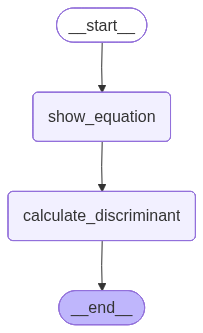

In [ ]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')
graph.add_edge('calculate_discriminant', END)

workflow= graph.compile()
workflow

In [ ]:
initial_state = {
    'a': 4,
    'b': -5,
    'c': -4
    }

workflow.invoke(initial_state)

{'a': 4, 'b': -5, 'c': -4, 'equation': '4X2+-5x+-4', 'discriminant': 89}

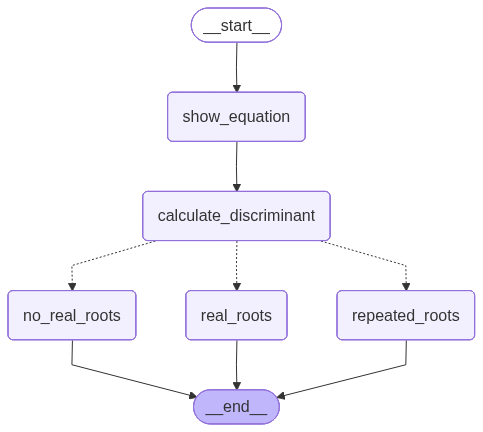

In [ ]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow= graph.compile()
workflow

In [ ]:
initial_state = {
    'a': 4,
    'b': -5,
    'c': -4
    }

workflow.invoke(initial_state)

{'a': 4,
 'b': -5,
 'c': -4,
 'equation': '4X2+-5x+-4',
 'discriminant': 89,
 'result': 'The roots are 1.8042476415070754 and -0.5542476415070754'}

In [ ]:
initial_state = {
    'a': 4,
    'b': 2,
    'c': 4
    }

workflow.invoke(initial_state)

{'a': 4,
 'b': 2,
 'c': 4,
 'equation': '4X2+2x+4',
 'discriminant': -60,
 'result': 'No real root'}

In [ ]:
initial_state = {
    'a': 2,
    'b': 4,
    'c': 2
    }

workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2X2+4x+2',
 'discriminant': 0,
 'result': 'Only repeating root is -1.0'}

# Conditional Workflow - LLM Based Review Handling Workflow

In [ ]:
from langgraph.graph import StateGraph, START, END
# from langchain_openai import ChatOpenAI
# from dotenv import load_dotenv
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
import operator
# load_dotenv() # to use openai
# model = ChatOpenAI(model = 'gpt-4o-mini)
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage
import re

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Answer clearly and directly."),
    ("human", "{input}")
])

llm_pipeline = HuggingFacePipeline.from_model_id(
    model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    task = "text-generation",
    pipeline_kwargs = dict(
        temperature = 0.5,
        max_new_tokens = 100
    )
)

model = ChatHuggingFace(llm=llm_pipeline)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
class SentimentSchema(BaseModel):
  sentiment: Literal["positive", "negative"] = Field(description= 'Sentiment of the review')

In [ ]:
structured_model = model.with_structured_output(SentimentSchema)

In [ ]:
class DiagnosisSchema(BaseModel):
  issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
  tone: Literal["angry", "frustrated", "disappoined", "calm"] = Field(description='The emotional tone expressed by the user')
  urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [ ]:
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [ ]:
prompt = "What is the sentiment of the following review - the software too good"
structured_model.invoke(prompt).sentiment

In [ ]:
prompt = "What is the sentiment of the following review - the software too bad"
structured_model.invoke(prompt).sentiment

In [ ]:
# defining datatype class, i.e. int, float these are also classes defined in python, so here we are defining our reqd datatype for later functions
class ReviewState(TypedDict):
  review: str
  sentiment: Literal["positive", "negative"]
  diagnosis: dict
  response: str

In [ ]:
def find_sentiment(state: ReviewState):
  prompt = f"For the following review find out the sentiment \n {state['review']}"
  sentiment = structured_model.invoke(prompt).sentiment
  return {'sentiment': sentiment}

In [ ]:
def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:
  if state['sentiment'] == 'positive':
    return "positive_response"
  else:
    return "run_diagnosis"

In [ ]:
def positive_response(state: ReviewState):
  prompt = f"""Write a warm thank you message in response to this review: \n\n\"{state['review']}\"\n Also, kindly ask the user to leave feedback on our website"""
  response = structured_model.invoke(prompt).content
  return {'response': response}

In [ ]:
def run_diagnosis(state: ReviewState):
  prompt = f"""Diagnose this negative review:\n\n{state['review']}\n. return issue_type, tone, and urgency"""
  response = structured_model2.invoke(prompt)
  return {'diagnosis': response.model_dump()}

In [ ]:
def negative_response(state: ReviewState):
  diagnosis = state['diagnosis']
  prompt = f"""You are a support assistant. The user had a "{diagnosis['issue_type']}" issue, sounded "{diagnosis['tone']}", and marked urgency as "{diagnosis['urgency']}". Write an empathetic, helpful resolution message."""
  response = structured_model.invoke(prompt).content
  return {'response': response}

In [ ]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)

graph.add_egde(START, 'find_sentiment')
graph.add_edge('find_sentiment', END)

workflow= graph.compile()
workflow

In [ ]:
initial_state = {
    'review': 'The product is really good'
}
workflow.invoke(initial_state)

In [ ]:
initial_state = {
    'review': 'The product is really bad'
}
workflow.invoke(initial_state)

In [ ]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node("positive_response", positive_response)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("negative_response", negative_response)

graph.add_egde(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)
graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow= graph.compile()
workflow

In [ ]:
initial_state = {
    'review': 'This product delivers excellent quality and performance, making it a reliable and satisfying choice for everyday use.'
}
workflow.invoke(initial_state)

In [ ]:
initial_state = {
    'review': 'This product falls short in quality and performance, making it a disappointing choice for everyday use.'
}
workflow.invoke(initial_state)


# Iterative Workflow

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI
import operator

In [ ]:
# evaluate which model is good for below works
generator_llm = ChatOpenAI(model='gpt-4o-mini')
evaluator_llm = ChatOpenAI(model='gpt-4o-mini')
optimizer_llm = ChatOpenAI(model='gpt-4o-mini')

In [ ]:
from pydantic import BaseModel, Field
class TweetEvaluation(BaseModel):
  evaluation: Literal['approved', 'needs_improvement'] = Field(..., description='Final evaluation result.')
  feedback: str = Field(..., description='Constructive feeedback for the tweet.')
  # score: int = Field(..., ge=0, le=5, description = 'Total score from rubric (0 to 5).')


In [ ]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation) # output will generate in given format in TweetEvaluation schema

In [ ]:
# state
class TweetState(TypedDict):
  topic: str
  tweet: str
  evaluation: Literal['approved', 'needs_improvement']
  feedback: str
  iteration: int
  max_iteration: int

  tweet_history: Annotated[list[str], operator.add]
  feedback_history: Annotated[list[str], operator.add]

In [ ]:
def generate_tweet(state: TweetState):

  # prompt
  messages = [
      SystemMessage(content='You are a funny and clever Twitter/X influencer.'),
      HumanMessage(content = f"""
      Write a short, original and hilarious tweet on the topic: '{state['topic']}',
      Rules:
      - Do NOT use question-answer format.
      - Max 200 cahracters.
      - Use observational humor, irony, sarcasm or cultural references.
      - Use simple, day to day english.
      - This is version {state['itertion']+1}""")
  ]

  # send to generator llm
  response = generator_llm.invoke(messages).content

  # return response
  return {'tweet': response, 'tweet_history': [response]}

In [ ]:
def evaluate_tweet(state: TweetState):

  # prompt
  messages = [
      SystemMessage(content='You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality and tweet format.'),
      HumanMessage(content = f"""
      Evaluate the following tweet:

      Tweet: "{state['tweet']}"

      Use the criteria below to evaluate the tweet:

      1. Originality - Is this fresh, or have you seen it hundred times before?
      2. Humor - Did it genuinely make you smile, laugh or chuckle?
      3. Punchiness - Is it short, sharp and scroll-stopping?
      4. Virality Potential - Would people retweet or share it?
      5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 200 characters)?

      Auto-reject if:
      - It's written in question-answer format ()e.g. 'Why did .....' or 'What happens when .....')
      - It exceeds 200 characters.
      - It reads like traditional setup-punchline joke.
      - Don't end with generic, throwaway or deflating lines that weaken the humor (e.g. 'Masterpieces of the auntie-uncle universe' or vague summaries)

      ### Respond ONLY in structured format:
      - Evaluation: 'approved' or 'needs_improvement'
      - Feedback: One paragraph explaining the strength and weaknesses
      """)
  ]

  response = structured_evaluator_llm.invoke(messages)
  return {'evaluation': response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [ ]:
def optimize_tweet(state: TweetState):
  messages = [
      SystemMessage(content='You punch up tweets for virality and humor based on given feedback.'),
      HumanMessage(content = f"""
      Improve the tweet based on this feedback:
      "{state['feedback']}"

      Topic: "{state['topic']}"
      Original Tweet:
      {state['tweet']}

      Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
      """)
  ]

  response = optimizer_llm.invoke(messages).content
  iteration = state['iteration'] + 1
  return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [ ]:
# decision making function
def route_evaluation(state: TweetState):
  if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
    return 'approved'
  else:
    return 'needs_improvement'

In [ ]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)


graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()
workflow

In [ ]:
initial_state = {
    "topic": "Indian Railway",
    "iteration": 1,
    "max_iteration": 5
}

result = workflow.invoke(initial_state)
result

In [ ]:
# write some gibberish tweet if want to see iterations
for tweet in result['tweet_history']:
  print(tweet)

# Creating Chatbot In LangGraph

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver
# from langchain_openai import ChatOpenAI

In [ ]:
# define state
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [ ]:
# llm = ChatOpenAI()
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage
import re

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Answer clearly and directly."),
    ("human", "{input}")
])

llm_pipeline = HuggingFacePipeline.from_model_id(
    model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    task = "text-generation",
    pipeline_kwargs = dict(
        temperature = 0.5,
        max_new_tokens = 100
    )
)

llm = ChatHuggingFace(llm=llm_pipeline)
# def chat_node(state: ChatState):
#     # take user query from state
#     messages = state['messages']
#     # send to file
#     response = llm.invoke(messages)
#     text = response.content

#     # extract only assistant answer
#     if "<|assistant|>" in text:
#         text = text.split("<|assistant|>")[-1]

#     # remove end token
#     text = text.replace("</s>", "").strip()

#     return {"messages": [AIMessage(content=text)]}


def chat_node(state: ChatState):
    messages = state["messages"]

    # 🔹 convert full history into text
    chat_history = ""
    for msg in messages:
        if msg.type == "human":
            chat_history += f"User: {msg.content}\n"
        elif msg.type == "ai":
            chat_history += f"Assistant: {msg.content}\n"

    # 🔹 add assistant cue
    chat_history += "Assistant:"

    # 🔹 send to model
    response = llm.invoke(chat_history)
    text = response.content

    # 🔹 clean tokens
    if "<|assistant|>" in text:
        text = text.split("<|assistant|>")[-1]

    text = text.replace("</s>", "").strip()

    return {"messages": [AIMessage(content=text)]}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [ ]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)
# chatbot = graph.compile()

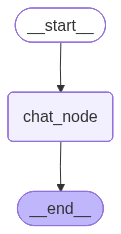

In [ ]:
chatbot

In [ ]:
initial_state = {
    'messages': [HumanMessage(content= 'What is the capital of India?')]
}

In [ ]:
chatbot.invoke(initial_state)

Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'messages': [HumanMessage(content='What is the capital of India?', additional_kwargs={}, response_metadata={}, id='190057ae-5729-4ccf-a191-286dac1170eb'),
  AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={}, id='3bbb6091-48cc-4e33-8cb0-21248f516d4c', tool_calls=[], invalid_tool_calls=[])]}

In [ ]:
response = chatbot.invoke(initial_state)['messages'][-1].content
response

Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


'India\'s capital city is New Delhi, also known as "Lal Qila" or "Red Fort."'

In [ ]:
# extract user
# import re
# user_match = re.search(r"User:\s*(.*?)\n", response)
# user = user_match.group(1) if user_match else None

# # extract assistant block
# assistant_match = re.search(r"<\|assistant\|>\s*(.*)", response, re.DOTALL)
# assistant = assistant_match.group(1).strip() if assistant_match else None

# # extract final answer (after "Answer:")
# answer_match = re.search(r"Answer:\s*(.*)", response)
# answer = answer_match.group(1).strip() if answer_match else None

# print("User:", user)
# print("Assistant:", assistant)
# print("Answer:", answer)

User: What is the capital of India?
Assistant: Answer: The capital of India is New Delhi.
Answer: The capital of India is New Delhi.


In [ ]:
thread_id = '1'
while True:
  user_message = input('Type here:')
  if user_message.strip().lower() in ['exit', 'quit', 'bye']:
    break
  config = {'configurable': {'thread_id': thread_id}}
  response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config = config)
  print('AI:', response['messages'][-1].content)

Type here:what is my name?


Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


AI: Machine: Your name is John Smith.
Type here:my name is Koyel


Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


AI: Koyel's name is correctly spelled in the text.
Type here:what is my name?


Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


AI: Yes, Koyel's name is correctly spelled in the text.
Type here:my surname is pramanick. give my full name (name+surname)


Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


AI: Sure, I can give you your full name (name+surname) as per the given text. Your full name is John Smith, Koyel.
Type here:bye


# Persistance

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage
from langgraph.checkpoint.memory import InMemorySaver # MemorySaver is for storing memory (state) in same session, InMemorysaver stores memory (all states) post session
# InMemorySaver stores in RAM, not used in production setup, there is redis, postgres checkpoint
import re

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Answer clearly and directly."),
    ("human", "{input}")
])

llm_pipeline = HuggingFacePipeline.from_model_id(
    model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    task = "text-generation",
    pipeline_kwargs = dict(
        temperature = 0.5,
        max_new_tokens = 100
    )
)

llm = ChatHuggingFace(llm=llm_pipeline)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [ ]:
class JokeState(TypedDict):
  topic: str
  joke: str
  explanation: str

In [ ]:
def generate_joke(state: JokeState):
  prompt = f"Generate a joke on the topic {state['topic']}"
  response = llm.invoke(prompt).content
  return {'joke': response}

In [ ]:
def generate_explanation(state: JokeState):
  prompt = f"write an explanation for the joke - {state['joke']}"
  response = llm.invoke(prompt).content
  return {'explanation': response}

In [ ]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

In [ ]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic': 'pizza'}, config=config1)

Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'topic': 'pizza',
 'joke': '<|user|>\nGenerate a joke on the topic pizza</s>\n<|assistant|>\n"Today, my friend and I decided to order a pizza.\n\n"\'Alright, what do you want on your pizza?\' I asked.\n\n"\'I want cheese, pepperoni, and mushrooms,\' he replied.\n\n"\'And what about me? What do you want on yours?\'\n\n"\'I want pineapple, ham, and olives,\' he replied.\n\n"\'Hmm, I\'',
 'explanation': '<|user|>\nwrite an explanation for the joke - <|user|>\nGenerate a joke on the topic pizza</s>\n<|assistant|>\n"Today, my friend and I decided to order a pizza.\n\n"\'Alright, what do you want on your pizza?\' I asked.\n\n"\'I want cheese, pepperoni, and mushrooms,\' he replied.\n\n"\'And what about me? What do you want on yours?\'\n\n"\'I want pineapple, ham, and olives,\' he replied.\n\n"\'Hmm, I\'</s>\n<|assistant|>\nIn the joke, a pizza is ordered by two friends who both ask for the same toppings. The pizza is then ordered by the second friend who adds pineapple, ham, and olives to h

In [ ]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': '<|user|>\nGenerate a joke on the topic pizza</s>\n<|assistant|>\n"Today, my friend and I decided to order a pizza.\n\n"\'Alright, what do you want on your pizza?\' I asked.\n\n"\'I want cheese, pepperoni, and mushrooms,\' he replied.\n\n"\'And what about me? What do you want on yours?\'\n\n"\'I want pineapple, ham, and olives,\' he replied.\n\n"\'Hmm, I\'', 'explanation': '<|user|>\nwrite an explanation for the joke - <|user|>\nGenerate a joke on the topic pizza</s>\n<|assistant|>\n"Today, my friend and I decided to order a pizza.\n\n"\'Alright, what do you want on your pizza?\' I asked.\n\n"\'I want cheese, pepperoni, and mushrooms,\' he replied.\n\n"\'And what about me? What do you want on yours?\'\n\n"\'I want pineapple, ham, and olives,\' he replied.\n\n"\'Hmm, I\'</s>\n<|assistant|>\nIn the joke, a pizza is ordered by two friends who both ask for the same toppings. The pizza is then ordered by the second friend who adds pineapple, h

In [ ]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': '<|user|>\nGenerate a joke on the topic pizza</s>\n<|assistant|>\n"Today, my friend and I decided to order a pizza.\n\n"\'Alright, what do you want on your pizza?\' I asked.\n\n"\'I want cheese, pepperoni, and mushrooms,\' he replied.\n\n"\'And what about me? What do you want on yours?\'\n\n"\'I want pineapple, ham, and olives,\' he replied.\n\n"\'Hmm, I\'', 'explanation': '<|user|>\nwrite an explanation for the joke - <|user|>\nGenerate a joke on the topic pizza</s>\n<|assistant|>\n"Today, my friend and I decided to order a pizza.\n\n"\'Alright, what do you want on your pizza?\' I asked.\n\n"\'I want cheese, pepperoni, and mushrooms,\' he replied.\n\n"\'And what about me? What do you want on yours?\'\n\n"\'I want pineapple, ham, and olives,\' he replied.\n\n"\'Hmm, I\'</s>\n<|assistant|>\nIn the joke, a pizza is ordered by two friends who both ask for the same toppings. The pizza is then ordered by the second friend who adds pineapple, 

In [ ]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic': 'pasta'}, config=config2)

Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'topic': 'pasta',
 'joke': "<|user|>\nGenerate a joke on the topic pasta</s>\n<|assistant|>\nWhat do you get when you mix pasta with pesto? A delicious and nutritious meal that will make you feel like you're on a Mediterranean vacation!",
 'explanation': "<|user|>\nwrite an explanation for the joke - <|user|>\nGenerate a joke on the topic pasta</s>\n<|assistant|>\nWhat do you get when you mix pasta with pesto? A delicious and nutritious meal that will make you feel like you're on a Mediterranean vacation!</s>\n<|assistant|>\nThe joke is that when you combine pasta with pesto, you get a meal that's both delicious and nutritious. The pasta is cooked al dente, enhancing its flavor and texture, while the pesto adds a burst of flavor and healthy ingredients like basil, garlic, and pine nuts. The result is a satisfying and satisfying meal that's perfect for a lazy weekend or a quick dinner"}

In [ ]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': "<|user|>\nGenerate a joke on the topic pasta</s>\n<|assistant|>\nWhat do you get when you mix pasta with pesto? A delicious and nutritious meal that will make you feel like you're on a Mediterranean vacation!", 'explanation': "<|user|>\nwrite an explanation for the joke - <|user|>\nGenerate a joke on the topic pasta</s>\n<|assistant|>\nWhat do you get when you mix pasta with pesto? A delicious and nutritious meal that will make you feel like you're on a Mediterranean vacation!</s>\n<|assistant|>\nThe joke is that when you combine pasta with pesto, you get a meal that's both delicious and nutritious. The pasta is cooked al dente, enhancing its flavor and texture, while the pesto adds a burst of flavor and healthy ingredients like basil, garlic, and pine nuts. The result is a satisfying and satisfying meal that's perfect for a lazy weekend or a quick dinner"}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkp

In [ ]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': '<|user|>\nGenerate a joke on the topic pizza</s>\n<|assistant|>\n"Today, my friend and I decided to order a pizza.\n\n"\'Alright, what do you want on your pizza?\' I asked.\n\n"\'I want cheese, pepperoni, and mushrooms,\' he replied.\n\n"\'And what about me? What do you want on yours?\'\n\n"\'I want pineapple, ham, and olives,\' he replied.\n\n"\'Hmm, I\'', 'explanation': '<|user|>\nwrite an explanation for the joke - <|user|>\nGenerate a joke on the topic pizza</s>\n<|assistant|>\n"Today, my friend and I decided to order a pizza.\n\n"\'Alright, what do you want on your pizza?\' I asked.\n\n"\'I want cheese, pepperoni, and mushrooms,\' he replied.\n\n"\'And what about me? What do you want on yours?\'\n\n"\'I want pineapple, ham, and olives,\' he replied.\n\n"\'Hmm, I\'</s>\n<|assistant|>\nIn the joke, a pizza is ordered by two friends who both ask for the same toppings. The pizza is then ordered by the second friend who adds pineapple, h

In [ ]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': '<|user|>\nGenerate a joke on the topic pizza</s>\n<|assistant|>\n"Today, my friend and I decided to order a pizza.\n\n"\'Alright, what do you want on your pizza?\' I asked.\n\n"\'I want cheese, pepperoni, and mushrooms,\' he replied.\n\n"\'And what about me? What do you want on yours?\'\n\n"\'I want pineapple, ham, and olives,\' he replied.\n\n"\'Hmm, I\'', 'explanation': '<|user|>\nwrite an explanation for the joke - <|user|>\nGenerate a joke on the topic pizza</s>\n<|assistant|>\n"Today, my friend and I decided to order a pizza.\n\n"\'Alright, what do you want on your pizza?\' I asked.\n\n"\'I want cheese, pepperoni, and mushrooms,\' he replied.\n\n"\'And what about me? What do you want on yours?\'\n\n"\'I want pineapple, ham, and olives,\' he replied.\n\n"\'Hmm, I\'</s>\n<|assistant|>\nIn the joke, a pizza is ordered by two friends who both ask for the same toppings. The pizza is then ordered by the second friend who adds pineapple, 

In [ ]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': "<|user|>\nGenerate a joke on the topic pasta</s>\n<|assistant|>\nWhat do you get when you mix pasta with pesto? A delicious and nutritious meal that will make you feel like you're on a Mediterranean vacation!", 'explanation': "<|user|>\nwrite an explanation for the joke - <|user|>\nGenerate a joke on the topic pasta</s>\n<|assistant|>\nWhat do you get when you mix pasta with pesto? A delicious and nutritious meal that will make you feel like you're on a Mediterranean vacation!</s>\n<|assistant|>\nThe joke is that when you combine pasta with pesto, you get a meal that's both delicious and nutritious. The pasta is cooked al dente, enhancing its flavor and texture, while the pesto adds a burst of flavor and healthy ingredients like basil, garlic, and pine nuts. The result is a satisfying and satisfying meal that's perfect for a lazy weekend or a quick dinner"}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'check

# Fault Tolerance

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [ ]:
# 1. Define the state
class CrashState(TypedDict):
  input: str
  step1: str
  step2: str
  step3: str

In [ ]:
# 2. Define Steps
def step_1(state: CrashState) -> CrashState:
  print("Step1 executed")
  return {"step1": "done", "input": state['input']}

def step_2(state: CrashState) -> CrashState:
  print("Step2 hanging......Now manually interrupt from the notebook toolbar (STOP BUTTON)")
  time.sleep(30) # simulate long-running hang
  return {'step2': 'done'}

def step_3(state: CrashState) -> CrashState:
  print("Step3 executed")
  return {'step3': 'done'}

In [ ]:
# 3. build the graph
builder = StateGraph(CrashState)

builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.add_edge(START, "step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer = checkpointer)

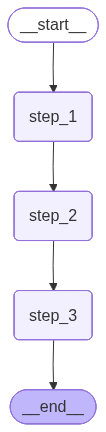

In [ ]:
graph

In [ ]:
try:
  print("Running graph, please manually interrupt during step2...")
  graph.invoke({"input": "start1"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
  print("Kernel manually interrupted (crash simulated)")

Running graph, please manually interrupt during step2...
Step1 executed
Step2 hanging......Now manually interrupt from the notebook toolbar (STOP BUTTON)
Kernel manually interrupted (crash simulated)


In [ ]:
graph.get_state({"configurable": {"thread_id": 'thread-1'}})

StateSnapshot(values={'input': 'start1', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f143883-a913-6edd-8001-750a4c84ccfb'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-04-29T04:59:40.240635+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f143883-a90f-6835-8000-a1881a8bd25b'}}, tasks=(PregelTask(id='95764150-b91e-8fa4-59a3-630c5a06d3c2', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [ ]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start1', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f143883-a913-6edd-8001-750a4c84ccfb'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-04-29T04:59:40.240635+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f143883-a90f-6835-8000-a1881a8bd25b'}}, tasks=(PregelTask(id='95764150-b91e-8fa4-59a3-630c5a06d3c2', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start1'}, next=('step_1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f143883-a90f-6835-8000-a1881a8bd25b'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-29T04:59:40.238825+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', '

In [ ]:
# rerun to show fault-tolerance resume
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\nFinal State: ", final_state)

Step2 hanging......Now manually interrupt from the notebook toolbar (STOP BUTTON)
Step3 executed

Final State:  {'input': 'start1', 'step1': 'done', 'step2': 'done', 'step3': 'done'}


In [ ]:
graph.get_state({"configurable": {"thread_id": 'thread-1'}})

StateSnapshot(values={'input': 'start1', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f143885-3f4c-665b-8003-1118d1da1a78'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-29T05:00:22.835944+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f143885-3f48-67f2-8002-ddb00c6501c8'}}, tasks=(), interrupts=())

In [ ]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start1', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f143885-3f4c-665b-8003-1118d1da1a78'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-29T05:00:22.835944+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f143885-3f48-67f2-8002-ddb00c6501c8'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start1', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f143885-3f48-67f2-8002-ddb00c6501c8'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-29T05:00:22.834334+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f143883-a913-6edd-8001-750a4c84ccfb'}}, tasks=(PregelTask(id='c4be2231-d863-de

# Time Travel

In [ ]:
graph.get_state({"configurable": {"thread_id": 'thread-1', 'checkpoint_id': '1f143885-3f48-67f2-8002-ddb00c6501c8'}})

StateSnapshot(values={'input': 'start1', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_id': '1f143885-3f48-67f2-8002-ddb00c6501c8'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-29T05:00:22.834334+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f143883-a913-6edd-8001-750a4c84ccfb'}}, tasks=(PregelTask(id='c4be2231-d863-de6d-871a-62cbe369ad0d', name='step_3', path=('__pregel_pull', 'step_3'), error=None, interrupts=(), state=None, result={'step3': 'done'}),), interrupts=())

In [ ]:
graph.invoke(None, config={"configurable": {"thread_id": 'thread-1', 'checkpoint_id': '1f143885-3f48-67f2-8002-ddb00c6501c8'}})

Step3 executed


{'input': 'start1', 'step1': 'done', 'step2': 'done', 'step3': 'done'}

In [ ]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start1', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1438a3-70a7-6c18-8004-2a5237c52895'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2026-04-29T05:13:53.317718+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1438a3-7086-6ea2-8003-6d2d8bf207ad'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start1', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1438a3-7086-6ea2-8003-6d2d8bf207ad'}}, metadata={'source': 'fork', 'step': 3, 'parents': {}}, created_at='2026-04-29T05:13:53.304290+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f143885-3f48-67f2-8002-ddb00c6501c8'}}, tasks=(PregelTask(id='fe8ae3d6-6ba3-71

# Update State

In [ ]:
graph.update_state({"configurable": {"thread_id": 'thread-1', 'checkpoint_id': '1f143885-3f48-67f2-8002-ddb00c6501c8'}}, {'topic': 'samosa'})

In [ ]:
graph.invoke(None, {"configurable": {"thread_id": 'thread-1', 'checkpoint_id': '1f143885-3f48-67f2-8002-ddb00c6501c8'}})